## CMPINF 2100 Weekk 10

### Making predictions with linear models

We will make predictions for the linear relationship example

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [29]:
import statsmodels.formula.api as smf

## Read data

In [30]:
df = pd.read_csv('week_10_linear_data.csv')

In [31]:
df

,x,trend,y,true_intercept,true_slope,true_sigma
0,-3.00,4.750,6.030315,0.25,-1.5,1.25
1,-2.25,3.625,1.457911,0.25,-1.5,1.25
2,-1.50,2.500,2.388383,0.25,-1.5,1.25
3,-0.75,1.375,0.007815,0.25,-1.5,1.25
4,0.00,0.250,0.651244,0.25,-1.5,1.25
5,0.75,-0.875,-2.254007,0.25,-1.5,1.25
6,1.50,-2.000,-2.969992,0.25,-1.5,1.25
7,2.25,-3.125,-3.537097,0.25,-1.5,1.25
8,3.00,-4.250,-6.063282,0.25,-1.5,1.25


## Fit the linear model

Let's fit the linear model with the linear relationship between the SINGLE input `x` and the MEAN OUTPUT of `y`

In [32]:
lm_fit = smf.ols(formula= 'y ~ x' , data=df).fit()

In [33]:
lm_fit.params

Intercept   -0.476523
x           -1.696400
dtype: float64

In [34]:
lm_fit.bse

Intercept    0.370031
x            0.191083
dtype: float64

In [35]:
lm_fit.pvalues

Intercept    0.238754
x            0.000047
dtype: float64

In [36]:
lm_fit.conf_int().\
rename(columns={0: 'ci_lwr', 1: 'ci_upr'})

,ci_lwr,ci_upr
Intercept,-1.351507,0.39846
x,-2.148239,-1.24456


## Making Predictions

Unfortunately, predictions are the LEAST used tools for interpreting model behavior!!!

Predictions can be made on data that DO NOT INCLUDE observed outputs!!!

We can create our own data sets and visualize the predictive trends, predictive uncertainty, the predictive behavior for ANY input value!!!

Let's create a data set that has MORE input locations than the training set

In [37]:
df_viz = pd.DataFrame({'x': np.linspace(df.x.min()-0.1, df.x.max()+0.1, num=101)})

In [38]:
df_viz

,x
0,-3.100
1,-3.038
2,-2.976
3,-2.914
4,-2.852
...,...
96,2.852
97,2.914
98,2.976
99,3.038


In [39]:
df

,x,trend,y,true_intercept,true_slope,true_sigma
0,-3.00,4.750,6.030315,0.25,-1.5,1.25
1,-2.25,3.625,1.457911,0.25,-1.5,1.25
2,-1.50,2.500,2.388383,0.25,-1.5,1.25
3,-0.75,1.375,0.007815,0.25,-1.5,1.25
4,0.00,0.250,0.651244,0.25,-1.5,1.25
5,0.75,-0.875,-2.254007,0.25,-1.5,1.25
6,1.50,-2.000,-2.969992,0.25,-1.5,1.25
7,2.25,-3.125,-3.537097,0.25,-1.5,1.25
8,3.00,-4.250,-6.063282,0.25,-1.5,1.25


## Purpose?

We can ask **WHAT IF** questions. What if the INPUT is at a NEW value that we DID NOT see previously???

What will the OUTPUT BE???

The statemodels fitted object includes the `.predict()` method. The method will let you PREDICT a new data set GIVEN the FITTED MODEL!!!

Make the prediction and assing the `lm_pred` object

In [40]:
lm_pred = lm_fit.predict( df_viz)

In [41]:
type(lm_pred)

pandas.core.series.Series

In [42]:
lm_pred.size

101

Let's make a copy of the visuzlization DataFrame and add the prediction to this copy

In [43]:
df_viz_copy = df_viz.copy()

In [44]:
df_viz_copy['pred_trend'] = lm_pred

In [45]:
df_viz_copy

,x,pred_trend
0,-3.100,4.782316
1,-3.038,4.677139
2,-2.976,4.571962
3,-2.914,4.466785
4,-2.852,4.361608
...,...,...
96,2.852,-5.314655
97,2.914,-5.419832
98,2.976,-5.525008
99,3.038,-5.630185


We can visualize the predictive TREND with respect to the INPUT

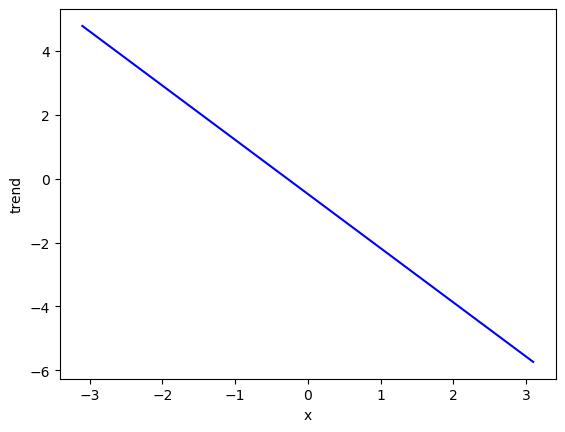

In [46]:
fig, ax = plt.subplots()

ax.plot( df_viz_copy.x, df_viz_copy.pred_trend, color='b')
ax.set_xlabel('x')
ax.set_ylabel('trend')
plt.show()

Include the TRAINING set as a scatter plot

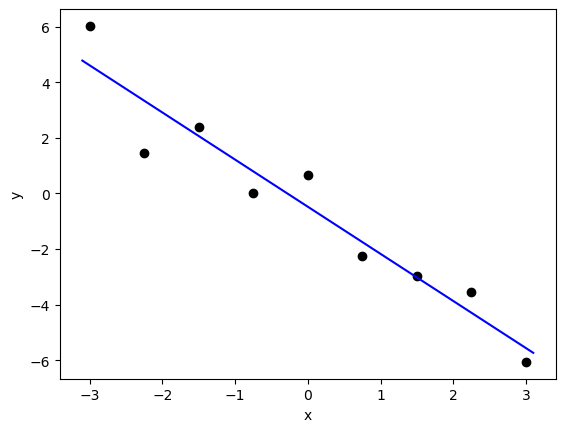

In [47]:
fig, ax = plt.subplots()

ax.plot( df_viz_copy.x, df_viz_copy.pred_trend, color='b')

ax.scatter( df.x, df.y, color='k')

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

Because this is a TOY PROBLEM and we generated the data...we KNOW the REAL answer or the TRUE TREND

In [48]:
df

,x,trend,y,true_intercept,true_slope,true_sigma
0,-3.00,4.750,6.030315,0.25,-1.5,1.25
1,-2.25,3.625,1.457911,0.25,-1.5,1.25
2,-1.50,2.500,2.388383,0.25,-1.5,1.25
3,-0.75,1.375,0.007815,0.25,-1.5,1.25
4,0.00,0.250,0.651244,0.25,-1.5,1.25
5,0.75,-0.875,-2.254007,0.25,-1.5,1.25
6,1.50,-2.000,-2.969992,0.25,-1.5,1.25
7,2.25,-3.125,-3.537097,0.25,-1.5,1.25
8,3.00,-4.250,-6.063282,0.25,-1.5,1.25


In [49]:
my_intercept = np.unique( df.true_intercept)

In [50]:
my_slope = np.unique(df.true_slope)

Display the TRUE TREND the TRUE MEAN relationship to the INPUT with the PREDICTIVE TREND

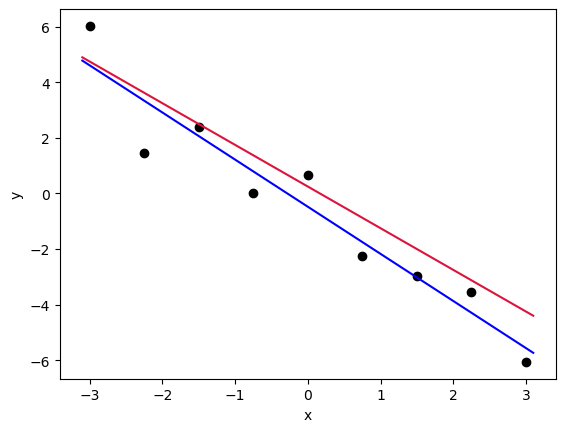

In [51]:
fig, ax = plt.subplots()

ax.plot( df_viz_copy.x, df_viz_copy.pred_trend, color='b', label='model')

ax.plot( df_viz_copy.x, my_intercept + my_slope * df_viz_copy.x, color='crimson', label='truth')

ax.scatter( df.x, df.y, color='k')

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

We will NEVER know the TRUE relationship...we MUST ALWAYS include the CONFIDENCE INTERVAL on teh TREND!!!

We must always represent the UNCERTAINTY on the TREND given the fitted data!!!